In [83]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor


In [84]:
results_df = pd.read_parquet('rmse_summary.parquet')

In [85]:
print(results_df)

   lead  validation       xgb  persistence
0     1    0.010155  0.019841     0.018475
1     2    0.014360  0.025267     0.023287
2     3    0.019106  0.030719     0.028356
3     4    0.024145  0.035775     0.033724
4     5    0.028586  0.039442     0.038484
5     6    0.033159  0.043143     0.043070
6     7    0.037115  0.045829     0.047097


In [86]:
features = (
    ["sla_now"]
    + [f"sla_lag{i}" for i in range(1,15)]
    + [
        "tmp_surface",
        "tmp_2m",
        "ugrd",
        "vgrd",
        "dswrf",
        "uswrf",
        "dlwrf",
        "ulwrf",
        "spfh",
        "prate",
        "month",
        "dayofyear",
        "latitude",
        "longitude"
    ]
)

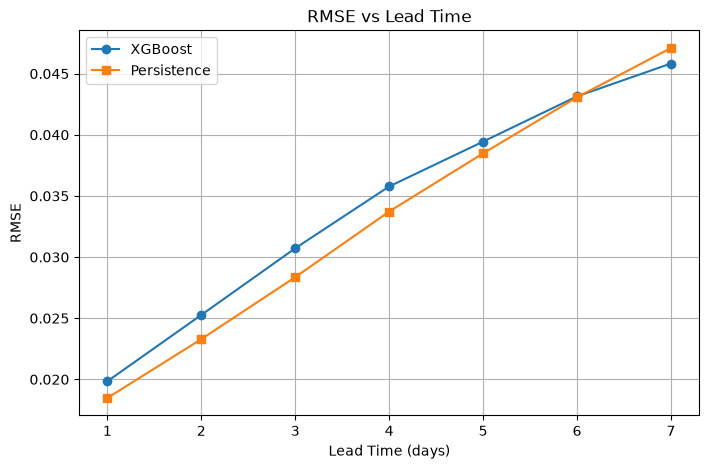

In [87]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["lead"],
    results_df["xgb"],
    marker="o",
    label="XGBoost"
)

plt.plot(
    results_df["lead"],
    results_df["persistence"],
    marker="s",
    label="Persistence"
)

plt.xlabel("Lead Time (days)")
plt.ylabel("RMSE")
plt.title("RMSE vs Lead Time")
plt.xticks(results_df["lead"])
plt.grid(True)
plt.legend()

plt.show()

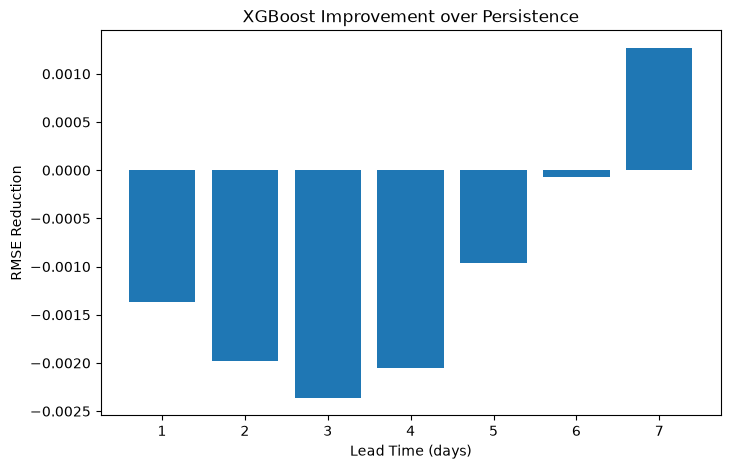

In [88]:
results_df["improvement"] = (
    results_df["persistence"] - results_df["xgb"]
)

plt.figure(figsize=(8,5))

plt.bar(
    results_df["lead"],
    results_df["improvement"]
)

plt.xlabel("Lead Time (days)")
plt.ylabel("RMSE Reduction")
plt.title("XGBoost Improvement over Persistence")

plt.show()

In [89]:
pred_dfs = {}

for lead in range(1, 8):
    pred_dfs[lead] = pd.read_parquet(
        f"xgb_results/pred_lead/predictions_lead_{lead}.parquet"
    )

In [90]:
pred_dfs[1].columns

Index(['time', 'latitude', 'longitude', 'truth', 'xgb', 'pers', 'err_xgb',
       'err_pers'],
      dtype='str')

In [91]:
lead1 = xr.open_dataset('xgb_results/improv_leadnc/improvement_lead_1.nc')

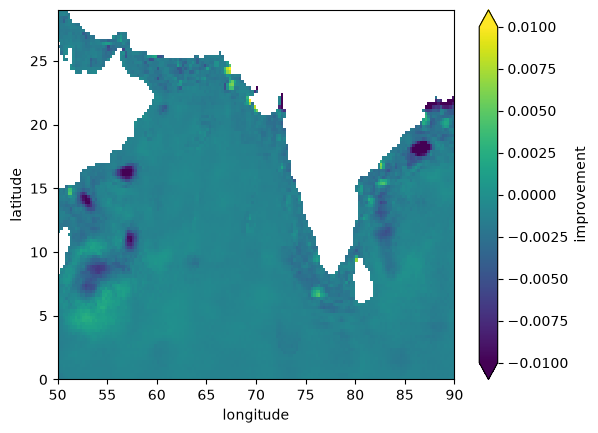

In [92]:
lead1.improvement.plot(vmin=-0.01,vmax=0.01)

In [93]:
lead1.improvement.isel(lead1.improvement.argmax(dim=["latitude","longitude"])).coords

Coordinates:
    latitude   float32 4B 21.88
    longitude  float32 4B 69.38

In [94]:
best = lead1.improvement.stack(
    point=("latitude", "longitude")
).idxmax()

In [95]:
print(best)

<xarray.DataArray 'point' ()> Size: 8B
array((21.875, 69.375), dtype=object)


In [96]:
lead1.improvement.isel(latitude=slice(18,20),longitude=slice(10,15))

<xarray.DataArray 'improvement' (latitude: 2, longitude: 5)> Size: 40B
[10 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 8B 4.625 4.875
  * longitude  (longitude) float32 20B 52.62 52.88 53.12 53.38 53.62

In [97]:
lead1.improvement.sel(latitude=4.625,longitude=52.88,method="nearest")


<xarray.DataArray 'improvement' ()> Size: 4B
[1 values with dtype=float32]
Coordinates:
    latitude   float32 4B 4.625
    longitude  float32 4B 52.88

In [98]:
df = pred_dfs[1]

In [99]:
point = df[
    (df["latitude"] == 4.625) &
    (df["longitude"] == 52.875)
    ].sort_values("time")

In [100]:
point

,time,latitude,longitude,truth,xgb,pers,err_xgb,err_pers
41193687,2024-01-01,4.625,52.875,-0.031700,-0.016917,-0.019000,0.014783,0.012700
41205781,2024-01-02,4.625,52.875,-0.030000,-0.031436,-0.031700,-0.001436,-0.001700
41217875,2024-01-03,4.625,52.875,-0.042000,-0.030000,-0.030000,0.012000,0.012000
41229969,2024-01-04,4.625,52.875,-0.044900,-0.044880,-0.042000,0.000020,0.002900
41242063,2024-01-05,4.625,52.875,-0.040500,-0.050014,-0.044900,-0.009514,-0.004400
...,...,...,...,...,...,...,...,...
49070520,2025-09-30,4.625,52.875,-0.193200,-0.177569,-0.177375,0.015631,0.015825
49082894,2025-10-01,4.625,52.875,-0.181425,-0.212503,-0.193200,-0.031078,-0.011775
49095268,2025-10-02,4.625,52.875,-0.161725,-0.217540,-0.181425,-0.055815,-0.019700
49107642,2025-10-03,4.625,52.875,-0.137700,-0.144618,-0.161725,-0.006918,-0.024025


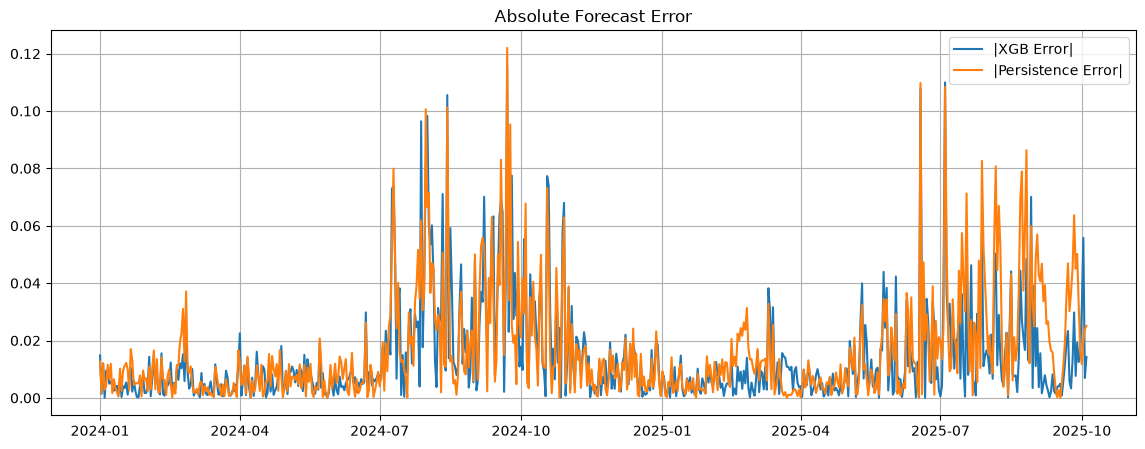

In [101]:
plt.figure(figsize=(14,5))

plt.plot(
    point["time"],
    np.abs(point["err_xgb"]),
    label="|XGB Error|"
)

plt.plot(
    point["time"],
    np.abs(point["err_pers"]),
    label="|Persistence Error|"
)

plt.legend()
plt.grid(True)
plt.title("Absolute Forecast Error")
plt.show()

In [102]:
rmse_xgb = np.sqrt((point["err_xgb"]**2).mean())
rmse_pers = np.sqrt((point["err_pers"]**2).mean())

print(rmse_xgb, rmse_pers)

0.022372225 0.02463845


In [103]:
lat = 4.625
lon = 52.875

point_results = []

for lead, df in pred_dfs.items():

    point = df[
        (df["latitude"] == lat) &
        (df["longitude"] == lon)
    ]

    rmse_xgb = np.sqrt((point["err_xgb"]**2).mean())
    rmse_pers = np.sqrt((point["err_pers"]**2).mean())

    point_results.append({
        "lead": lead,
        "xgb": rmse_xgb,
        "persistence": rmse_pers
    })

point_results = pd.DataFrame(point_results)

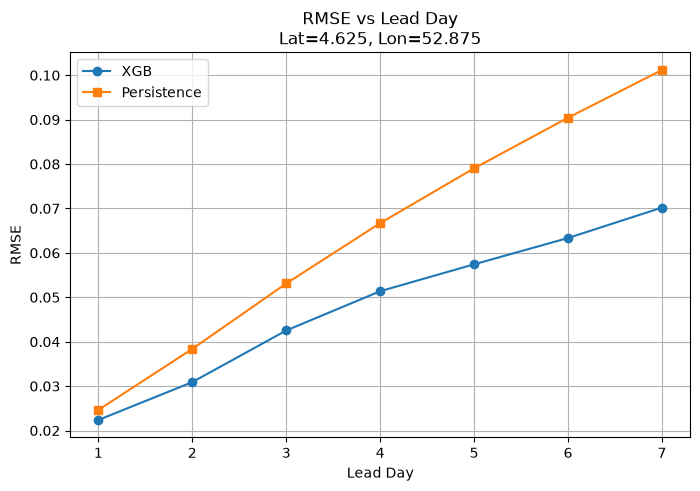

In [104]:
plt.figure(figsize=(8,5))

plt.plot(
    point_results["lead"],
    point_results["xgb"],
    marker="o",
    label="XGB"
)

plt.plot(
    point_results["lead"],
    point_results["persistence"],
    marker="s",
    label="Persistence"
)

plt.xlabel("Lead Day")
plt.ylabel("RMSE")
plt.title(
    f"RMSE vs Lead Day\nLat={lat}, Lon={lon}"
)

plt.grid(True)
plt.legend()
plt.show()

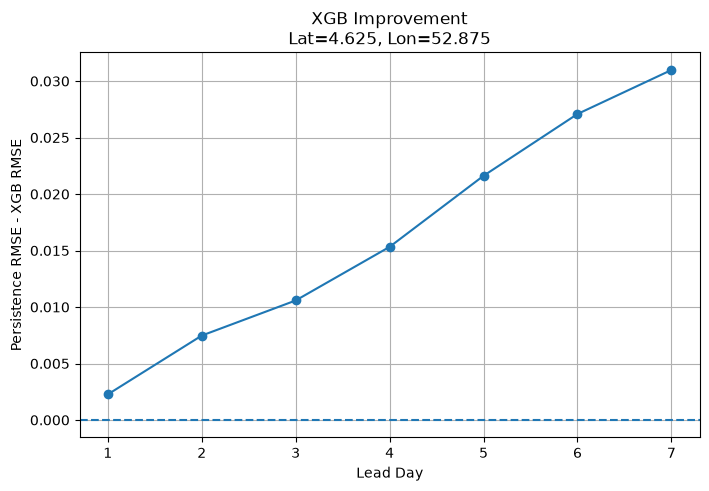

In [105]:
point_results["improvement"] = (
    point_results["persistence"]
    - point_results["xgb"]
)

plt.figure(figsize=(8,5))

plt.plot(
    point_results["lead"],
    point_results["improvement"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Lead Day")
plt.ylabel("Persistence RMSE - XGB RMSE")
plt.title(
    f"XGB Improvement\nLat={lat}, Lon={lon}"
)

plt.grid(True)
plt.show()

Number of grid points in box: 72


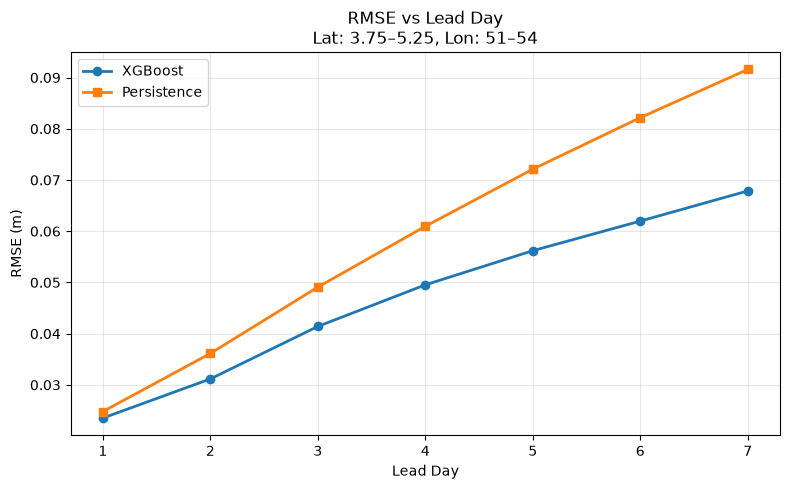

In [106]:
lat_min, lat_max = 3.75, 5.25
lon_min, lon_max = 51, 54

point_results = []

for lead, df in pred_dfs.items():

    region = df[
        (df["latitude"] >= lat_min) &
        (df["latitude"] <= lat_max) &
        (df["longitude"] >= lon_min) &
        (df["longitude"] <= lon_max)
    ]

    rmse_xgb = np.sqrt((region["err_xgb"]**2).mean())
    rmse_pers = np.sqrt((region["err_pers"]**2).mean())

    n_points = (
        region[["latitude", "longitude"]]
        .drop_duplicates()
        .shape[0]
    )

    point_results.append({
        "lead": lead,
        "xgb": rmse_xgb,
        "persistence": rmse_pers,
        "n_points": n_points
    })

point_results = pd.DataFrame(point_results)

print(f"Number of grid points in box: {point_results['n_points'].iloc[0]}")

plt.figure(figsize=(8, 5))

plt.plot(
    point_results["lead"],
    point_results["xgb"],
    marker="o",
    linewidth=2,
    label="XGBoost"
)

plt.plot(
    point_results["lead"],
    point_results["persistence"],
    marker="s",
    linewidth=2,
    label="Persistence"
)

plt.xlabel("Lead Day")
plt.ylabel("RMSE (m)")
plt.title(
    f"RMSE vs Lead Day\n"
    f"Lat: {lat_min}–{lat_max}, Lon: {lon_min}–{lon_max}"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Number of grid points in box: 32


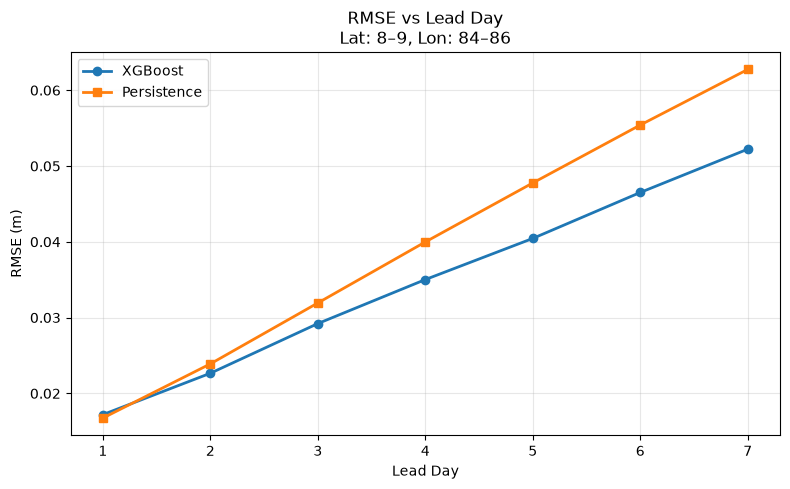

In [107]:
lat_min, lat_max = 8, 9
lon_min, lon_max = 84, 86

point_results = []

for lead, df in pred_dfs.items():

    region = df[
        (df["latitude"] >= lat_min) &
        (df["latitude"] <= lat_max) &
        (df["longitude"] >= lon_min) &
        (df["longitude"] <= lon_max)
    ]

    rmse_xgb = np.sqrt((region["err_xgb"]**2).mean())
    rmse_pers = np.sqrt((region["err_pers"]**2).mean())

    n_points = (
        region[["latitude", "longitude"]]
        .drop_duplicates()
        .shape[0]
    )

    point_results.append({
        "lead": lead,
        "xgb": rmse_xgb,
        "persistence": rmse_pers,
        "n_points": n_points
    })

point_results = pd.DataFrame(point_results)

print(f"Number of grid points in box: {point_results['n_points'].iloc[0]}")

plt.figure(figsize=(8, 5))

plt.plot(
    point_results["lead"],
    point_results["xgb"],
    marker="o",
    linewidth=2,
    label="XGBoost"
)

plt.plot(
    point_results["lead"],
    point_results["persistence"],
    marker="s",
    linewidth=2,
    label="Persistence"
)

plt.xlabel("Lead Day")
plt.ylabel("RMSE (m)")
plt.title(
    f"RMSE vs Lead Day\n"
    f"Lat: {lat_min}–{lat_max}, Lon: {lon_min}–{lon_max}"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [108]:
region_points = (
    pred_dfs[1][
        (pred_dfs[1]["latitude"] >= lat_min) &
        (pred_dfs[1]["latitude"] <= lat_max) &
        (pred_dfs[1]["longitude"] >= lon_min) &
        (pred_dfs[1]["longitude"] <= lon_max)
    ][["latitude","longitude"]]
    .drop_duplicates()
    .sort_values(["latitude","longitude"])
)

print(region_points)

          latitude  longitude
41195967     8.125     84.125
41195968     8.125     84.375
41195969     8.125     84.625
41195970     8.125     84.875
41195971     8.125     85.125
41195972     8.125     85.375
41195973     8.125     85.625
41195974     8.125     85.875
41196111     8.375     84.125
41196112     8.375     84.375
41196113     8.375     84.625
41196114     8.375     84.875
41196115     8.375     85.125
41196116     8.375     85.375
41196117     8.375     85.625
41196118     8.375     85.875
41196255     8.625     84.125
41196256     8.625     84.375
41196257     8.625     84.625
41196258     8.625     84.875
41196259     8.625     85.125
41196260     8.625     85.375
41196261     8.625     85.625
41196262     8.625     85.875
41196399     8.875     84.125
41196400     8.875     84.375
41196401     8.875     84.625
41196402     8.875     84.875
41196403     8.875     85.125
41196404     8.875     85.375
41196405     8.875     85.625
41196406     8.875     85.875


In [109]:
importance_df = pd.DataFrame(index=features)
for lead in range(1, 8):

    model = XGBRegressor()
    model.load_model(f"xgb_results/model_info/xgb_lead_{lead}.json")

    fi = pd.Series(
        model.feature_importances_,
        index=features,
        name=f"lead_{lead}"
    )

    importance_df[f"lead_{lead}"] = fi

importance_df

,lead_1,lead_2,lead_3,lead_4,lead_5,lead_6,lead_7
sla_now,0.761720,0.733795,0.703003,0.661224,0.625121,0.591887,0.566763
sla_lag1,0.136043,0.140335,0.131412,0.133303,0.135763,0.141388,0.145604
sla_lag2,0.060347,0.063519,0.073492,0.082951,0.088650,0.091302,0.093812
sla_lag3,0.022071,0.030380,0.040907,0.047560,0.052129,0.056687,0.057183
sla_lag4,0.003869,0.007514,0.011572,0.013429,0.014293,0.014517,0.017291
sla_lag5,0.005990,0.006489,0.006660,0.008020,0.008290,0.009318,0.010272
sla_lag6,0.000847,0.001412,0.002135,0.003137,0.004072,0.004703,0.005036
sla_lag7,0.000414,0.001539,0.003383,0.005553,0.006594,0.007982,0.007674
sla_lag8,0.000607,0.001864,0.003615,0.006099,0.008159,0.009437,0.009572
sla_lag9,0.000472,0.001317,0.002425,0.003481,0.004768,0.006279,0.006352
